# Feature Importance Ranking Analysis

This notebook evaluates the predictive power of each behavioral biometric feature using **Random Forest**. The goal is to rank the features based on how well they identify the 88 users in the dataset.

## Objective:
1. Load the normalized dataset.
2. Filter for legitimate user data (`label == 1`).
3. Run a Random Forest Classifier to calculate feature importance.
4. Scale the importance values between **0 and 1**.
5. Export the ranking to a CSV file for feature selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import os

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Loading and Preparation

We load the normalized feature extraction file and isolate the target variable (`user_id`).

In [2]:
input_path = r'../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/normalization/normalized_feature_extraction_V4_88_users.csv'
output_dir = r'../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/feature_importance_ranking/'
output_file = os.path.join(output_dir, 'feature_importance_values.csv')

if not os.path.exists(input_path):
    print(f"Error: {input_path} not found.")
else:
    df_full = pd.read_csv(input_path)
    
    # Filter for label 1 (Legitimate User Data only for identification task)
    df = df_full[df_full['label'] == 1].copy()
    
    # Handle missing values (fill with 0 as data is normalized)
    X = df.drop(columns=['user_id', 'label'])
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    y = df['user_id']

    print(f"Dataset loaded successfully.")
    print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Dataset loaded successfully.
Features: 111, Samples: 880


## 2. Calculating Feature Importance (Random Forest)

We use a Random Forest Classifier to determine the contribution of each feature to the classification of the 88 users.

In [3]:
print("Training Random Forest to calculate importance...")

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Extract Gini Importance
importances = rf.feature_importances_

# Scale values between 0 and 1 using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_importances = scaler.fit_transform(importances.reshape(-1, 1)).flatten()

# Create Ranking DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Value': scaled_importances
})

# Sort by value descending
importance_df = importance_df.sort_values(by='Value', ascending=False).reset_index(drop=True)

print("Feature importance calculation complete.")
importance_df.head(10)

Training Random Forest to calculate importance...
Feature importance calculation complete.


,Feature,Value
0,dwell_moment_mean,1.000000
1,dwell_lognorm_scale,0.828096
2,rr_lognorm_scale,0.720054
3,dwell_moment_std,0.534359
4,rr_moment_mean,0.486994
5,pp_lognorm_scale,0.470435
6,dwell_gamma_shape,0.447608
7,dwell_gamma_scale,0.429947
8,digraph_lognorm_scale,0.418877
9,dwell_lognorm_s,0.408717


## 3. Visualization of Top Features

C:\Users\Ravin\AppData\Local\Temp\ipykernel_4220\3673138549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Feature', data=importance_df.head(20), palette='viridis')


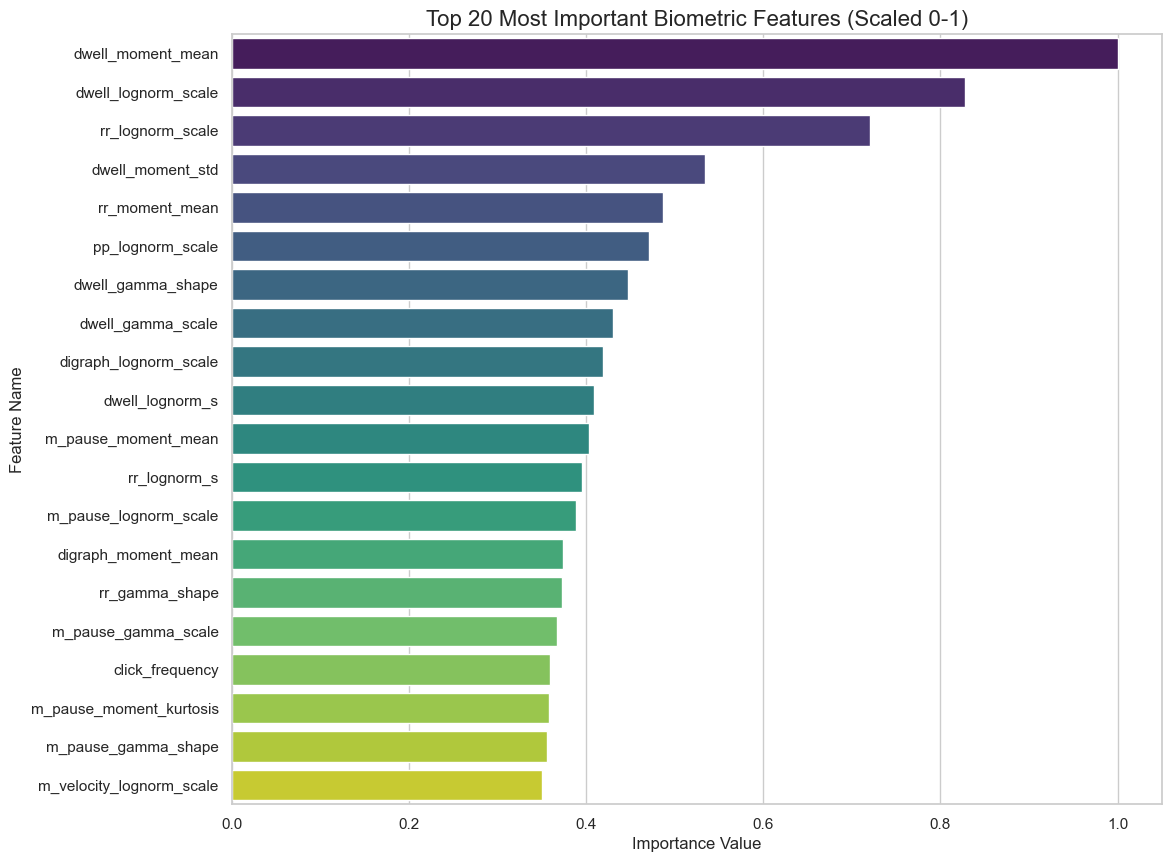

In [4]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Value', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Biometric Features (Scaled 0-1)', fontsize=16)
plt.xlabel('Importance Value', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

## 4. Exporting the Ranking

We save the results to the specified CSV file with the two-column format requested.

In [5]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

importance_df.to_csv(output_file, index=False)
print(f"Feature importance ranking saved to: {output_file}")

# Verify columns
print("CSV Columns:", list(importance_df.columns))

Feature importance ranking saved to: ../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/feature_importance_ranking/feature_importance_values.csv
CSV Columns: ['Feature', 'Value']
